In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

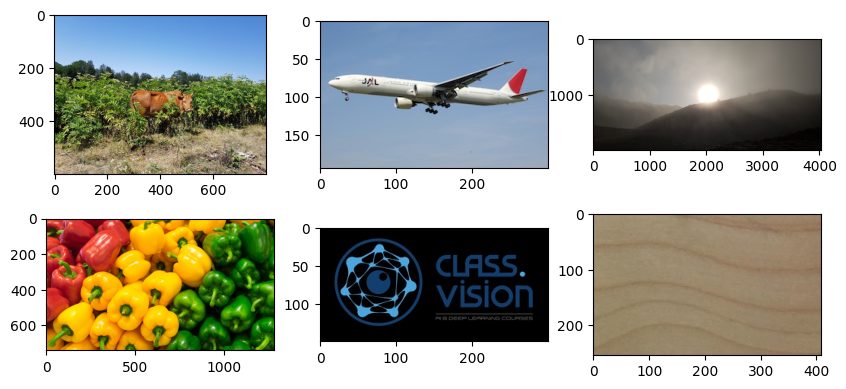

In [2]:
prefix_pth = "../../../class.vision/"
cow_img = cv.imread(prefix_pth + "images/input.jpg")
airplane_img = cv.imread(prefix_pth + "images/airplane.jpg")
mountain_img = cv.imread(prefix_pth + "images/aa.jpg")
bell_peper_img = cv.imread(prefix_pth + "images/felfel-dolme.jpg")
cv_img = cv.imread(prefix_pth + "images/class.vision.jpg")
wood_imf = cv.imread(prefix_pth + "images/wood-texture.jpg")
imgs = [cow_img,airplane_img,mountain_img,bell_peper_img,cv_img,wood_imf,]
plt.figure(figsize=(10,7))
for idx, img in enumerate(imgs):
    if img is not None:
        plt.subplot(1+len(imgs)//3,3,idx + 1);plt.imshow(img[...,::-1])


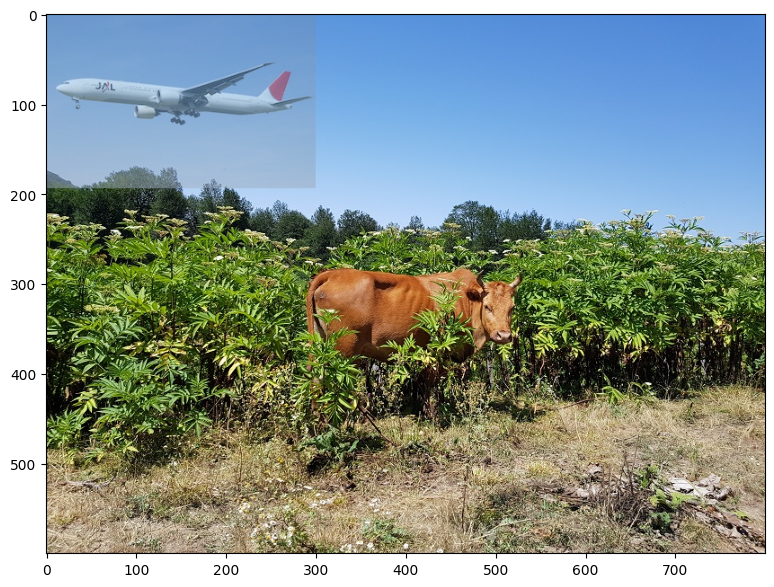

In [3]:
H, W = airplane_img.shape[:2]
bg = cow_img[0:H, 0:W, :]
fg = airplane_img.copy()

blended = cv.addWeighted(bg, 0.5, fg, 0.5, 0)
output = cow_img.copy()
output[0:H, 0:W, :] = blended

plt.figure(figsize=(10,7))
plt.imshow(output[...,::-1])

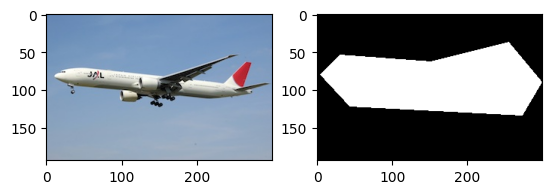

In [4]:
airplane_mask = np.zeros(airplane_img.shape, airplane_img.dtype)

points = np.array([
    [4,80], [30,54], [151,63], [254,37], [298,90], [272,134], [43,122]
])

cv.fillPoly(airplane_mask, [points], [255]*3)

plt.subplot(121);plt.imshow(airplane_img[...,::-1])
plt.subplot(122);plt.imshow(airplane_mask[...,::-1])

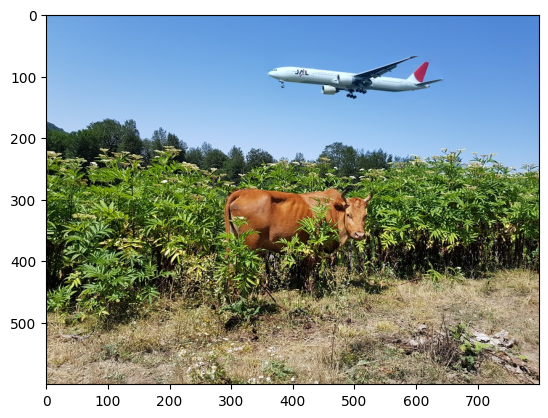

In [5]:
output = cv.seamlessClone(airplane_img, cow_img, airplane_mask, (500,100) ,cv.NORMAL_CLONE)
plt.imshow(output[...,::-1])

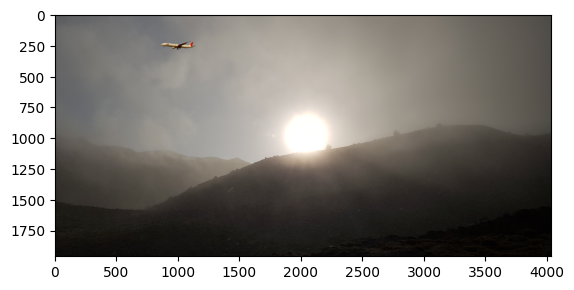

In [6]:
output = cv.seamlessClone(airplane_img, mountain_img, airplane_mask, (1000,250) ,cv.NORMAL_CLONE)
plt.imshow(output[...,::-1])

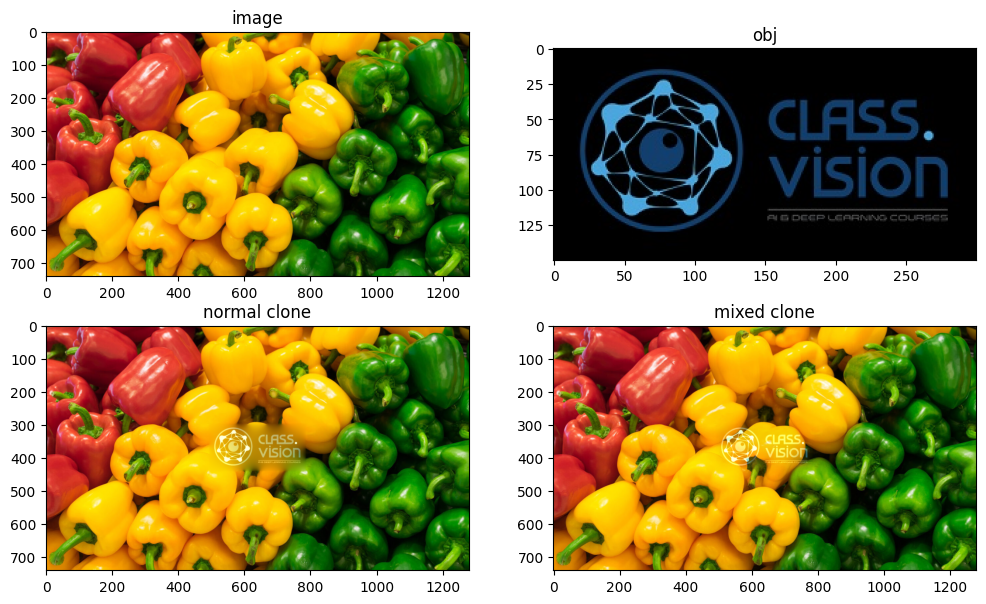

In [7]:
mask = 255 * np.ones(cv_img.shape, cv_img.dtype)
H, W = bell_peper_img.shape[:2]
img_center = (W//2, H//2)
normal_clone = cv.seamlessClone(cv_img, bell_peper_img, mask, img_center, cv.NORMAL_CLONE)
mixed_clone = cv.seamlessClone(cv_img, bell_peper_img, mask, img_center, cv.MIXED_CLONE)

plt.figure(figsize=[12,7])
plt.subplot(221);plt.imshow(bell_peper_img[...,::-1]);plt.title("image");
plt.subplot(222);plt.imshow(cv_img[...,::-1]);plt.title("obj");
plt.subplot(223);plt.imshow(normal_clone[...,::-1]);plt.title("normal clone");
plt.subplot(224);plt.imshow(mixed_clone[...,::-1]);plt.title("mixed clone");